# Apprentissage Non-Supervisé: KMeans (Clustering) 

## **Objectif du TP :**
- Apprendre à utiliser l'algorithme de clustering **K-means**.
- Déterminer le nombre optimal de clusters en utilisant :
  - La **méthode du coude**.
  - La **méthode de la silhouette**.
- Implémenter un programme Python permettant de réaliser des analyses prédictive.

## **1. Introduction**

L'algorithme K-means est une méthode populaire de **clustering** qui permet de regrouper des données en fonction de leur similarité. L'un des défis de cette méthode est de choisir le bon nombre de clusters \( k \). Ce TP vous permettra d'implémenter les deux méthodes pour déterminer la meilleure valeur de \( k \) pour un jeu de données.

## **2. Description des données**

Dans ce TP, nous allons travailler avec les données de clients d'une entreprise, qui incluent les informations suivantes :

| Client | Âge (années) | Revenu (milliers dt) |
|--------|--------------|---------------------|
| 1      | 25           | 30                  |
| 2      | 45           | 50                  |
| 3      | 35           | 60                  |
| 4      | 50           | 100                 |
| 5      | 29           | 80                  |
| 6      | 55           | 120                 |
| 7      | 41           | 90                  |
| 8      | 60           | 150                 |

Les colonnes importantes pour notre analyse sont :
- **Âge (années)** : L'âge des clients.
- **Revenu (milliers dt)** : Le revenu annuel des clients.

    - Quelles sont les caractéristiques principales des données fournies ? 
    - Pourquoi pensez-vous que ces deux colonnes (Âge et Revenu) sont pertinentes pour le clustering ? 
     

## **2.1 Chargement des bibliothèques**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## **2.2 Saisie des données par l'utilisateur**

In [5]:
## Créer un DataFrame vide
columns = ['Client', 'Âge (années)', 'Revenu (milliers dt)']
df = pd.DataFrame(columns=columns)
## saisir le vecteur des numéros des clients 
C=np.linspace(1,8,8)
## saisir le vecteur des ages des clients 
A=np.array([25,45,35,50,29,55,41,60])
## saisir le vecteur des ages des clients 
R=np.array([30,50,60,100,80,120,90,150])
## remplir la base des données 
df['Client']=C
df['Âge (années)']=A
df['Revenu (milliers dt)']=R
print(df)

   Client  Âge (années)  Revenu (milliers dt)
0     1.0            25                    30
1     2.0            45                    50
2     3.0            35                    60
3     4.0            50                   100
4     5.0            29                    80
5     6.0            55                   120
6     7.0            41                    90
7     8.0            60                   150


## **2.3 Afficher les observations**

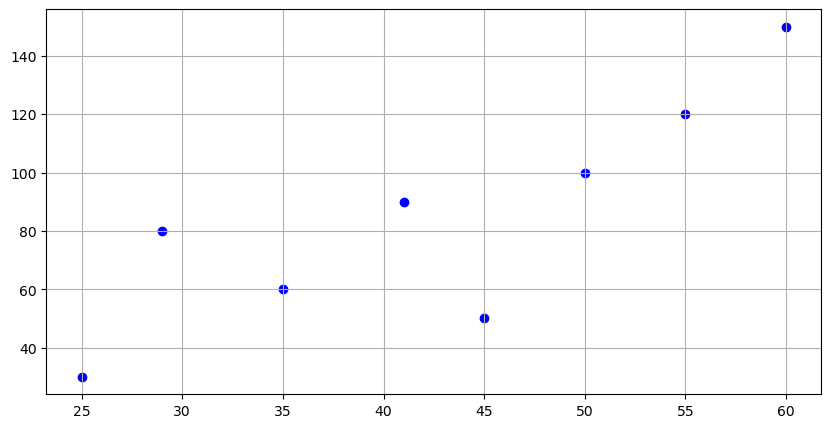

In [10]:
plt.figure(figsize=(10,5))
#nuage des observation des revenues en fonctions des ages des clients 
plt.scatter(df['Âge (années)'], df['Revenu (milliers dt)'], color='blue')
plt.grid(True)
plt.show()

# **3. Application de K-means pour la segmentation**

Pour savoir comment classer nos données, nous utilisons l'algorithme **K-means**, qui a pour objectif de diviser un ensemble de données en un nombre pré-défini de groupes appelés **clusters**. Il minimise la variance intra-cluster, c'est-à-dire qu'il essaie de rapprocher les points de données au sein de chaque cluster tout en éloignant les clusters les uns des autres.

Pour appliquer ce modèle, nous définissons plusieurs **hyperparamètres** qui influencent son comportement. Voici une liste des principaux hyperparamètres de l'algorithme **K-means** :

```p Means

kmeans = KMeans(
    n_clusters=8,               # Nombre de clusters, par défaut 8
    init='k-means++',           # Méthode d'initialisation des centroïdes, par défaut 'k-means++'
    n_init='auto',              # Nombre d'initialisations du modèle, par défaut 'auto'
    max_iter=300,               # Nombre maximum d'itérations pour l'algorithme, par défaut 300
    tol=0.0001,                 # Tolérance pour la convergence, par défaut 0.0001
    random_state=None,          # Graine pour la reproductibilité des résultats, par défaut None
    copy_x=True,                # Indique si une copie des données d'entrée est effectuée, par défaut True
    algorithm='lloyd'           # Algorithme à utiliser pour la mise à jour des centroïdes, par défaut 'lloyd'
)

kmeans.fit(X)  # Entraînement

# Résultats
print(kmeans.cluster_centers_)   # Affiche les centroïdes des clusters
print(kmeans.labels_)            # Affiche les labels des clusters
Labels des clusters
t de données à un cluster



## **3.1 Charger la classe KMeans à partir de module cluster de la bibliothèque sklearn, puis créer une instance km de la classe KMeans avec un nombre de clusters = 3 en fixant l'aléatoire à 0**

In [21]:
from sklearn.cluster import KMeans
km = KMeans(n_clusters=3, random_state=0, n_init='auto')

## **3.2 Entrainer le modèle**

In [23]:
import warnings
warnings.filterwarnings("ignore")
km.fit(df[columns[1:]])

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


## **3.3 Prédire les étiquettes des valeurs de données sur la base du modèle formé**

In [24]:
labels = km.predict(df[columns[1:]])

## **3.4 Calculer le score de modèle**

In [25]:
#La somme de la variance inter et intra classe
km.score(df[columns[1:]])
# première méthode     
#km.inertia_
km.inertia_ # deuxième méthode

1551.1666666666667

## **3.5 Afficher les coordonnées des clusters**

In [26]:
km.cluster_centers_

array([[ 40.        ,  90.        ],
       [ 57.5       , 135.        ],
       [ 35.        ,  46.66666667]])

## **3.6 Tracer les trois clusters ainsi que leurs centres**

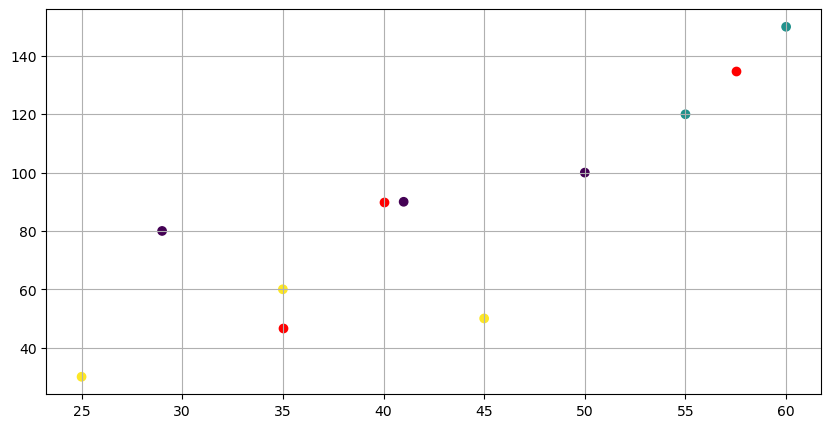

In [27]:
plt.figure(figsize=(10,5))

plt.scatter(df['Âge (années)'], df['Revenu (milliers dt)'], c=km.predict(df[columns[1:]]))

plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1], c='r')

plt.grid(True)

**1. Pourquoi on a choisi 3 clusters pour cette tâche de clustering ?**
On a choisi 3 clusters parce que les données semblent se diviser naturellement en 3 groupes de clients : les jeunes à faible revenu, les clients intermédiaires, et les clients âgés à revenu élevé. C'est un choix de départ qu'on va ensuite vérifier avec la méthode du coude et la silhouette.

**2. Est-ce que les résultats obtenus avec les paramètres par défaut (à l'exception du nombre de clusters et l'aléatoire) sont similaires à ceux vus dans le cours ?**

Oui, car les paramètres par défaut de scikit-learn utilisent l'algorithme classique K-means (algorithme de Lloyd) avec l'initialisation k-means++, ce qui correspond exactement à ce qui est vu en cours. Les clusters obtenus sont donc les mêmes.


**3. Quels hyperparamètres pourriez-vous ajuster pour optimiser les résultats de l'algorithme ?**

n_clusters : choisir le bon k grâce à la méthode du coude ou la silhouette.
n_init : augmenter le nombre d'initialisations pour obtenir un meilleur résultat.
random_state : fixer une valeur (ex: 0) pour avoir des résultats reproductibles.
max_iter : augmenter si l'algorithme ne converge pas bien.

# **4. Chercher le nombre optimale des clusters**

## **4.1 Méthode du coude (Elbow Method) utilisée pour savoir le nombre de clusters**
Cette méthode permet de déterminer le nombre optimal de clusters en analysant l'inertie (la somme des distances entre les points et le centroïde des clusters). L'idée est de calculer l'inertie pour différentes valeurs de \( k \) et de chercher le "coude", c'est-à-dire la valeur où l'inertie cesse de diminuer rapidement.

## **Créer une liste inertia(inertie) qui contient les inertias de modèle pour des valeurs de K (nombre de clusters) allant de 1 à 8 en fixant l'aléatoire à 0** 

In [28]:
inertia = []
K = range(2, 8)
for k in K:
    km = KMeans(n_clusters=k,random_state=0)
    km.fit(df[columns[1:]])
    inertia.append(km.inertia_) 
print(inertia)

[4405.333333333332, 1551.1666666666667, 1234.0, 757.1666666666667, 190.5, 90.5]


###  **Tracer la courbe elbow associée à inertia et K**

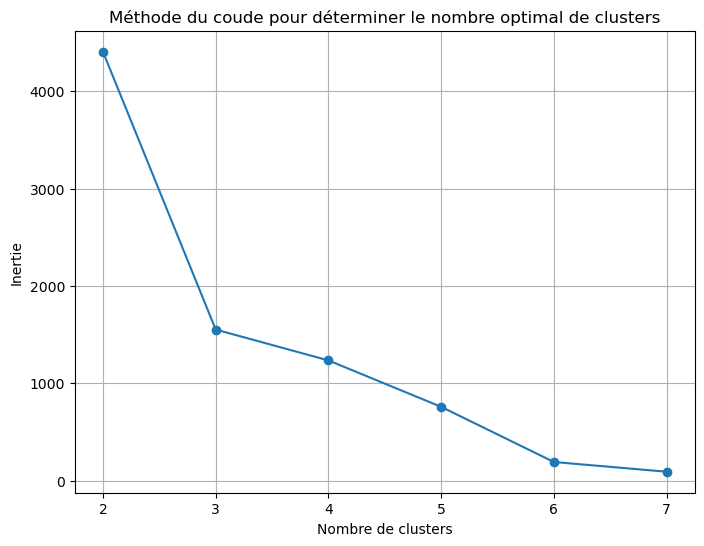

In [29]:
plt.figure(figsize=(8, 6))
plt.plot(K, inertia, marker='o')   
plt.title('Méthode du coude pour déterminer le nombre optimal de clusters')
plt.xlabel('Nombre de clusters')
plt.ylabel('Inertie')
plt.grid(True)
plt.show()

## **4.2 Méthode de la silhouette (Silhouette Method)**
Cette méthode évalue la qualité du clustering en calculant le score de silhouette. Un score élevé (proche de 1) indique que les points sont bien regroupés, tandis qu'un score proche de -1 indique des points mal classés.


## **Créer une liste pour stocker les scores de silhouette de modèle pour des valeurs de K (nombre de clusters) allant de 2 à 8 en fixant l'aléatoire à 0**

In [30]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score  # Import silhouette_score

# Assuming df is a pandas DataFrame and columns[1:] selects relevant columns
clients_data = df[columns[1:]]
silhouette_scores = []   
K = range(2, 8)

for k in K:  
    kmeans = KMeans(n_clusters=k, random_state=0)  
    kmeans.fit(clients_data)
    score = silhouette_score(clients_data, kmeans.labels_)  # Use silhouette_score
    silhouette_scores.append(score)

# Print or return the silhouette scores
print(silhouette_scores)

[0.44906390108078476, 0.4176800759193032, 0.11148158451406555, 0.14719490601041466, 0.16360473646006024, 0.060765419144884786]


## **Tracer les scores de silhouette**

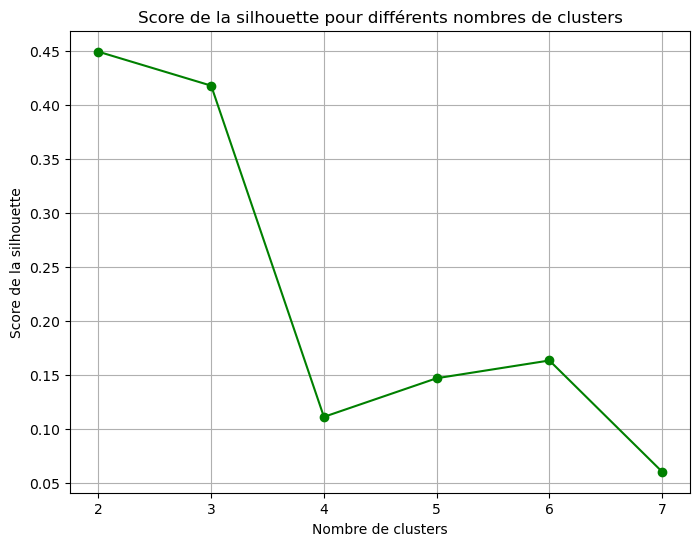

In [31]:
plt.figure(figsize=(8, 6))
plt.plot(K, silhouette_scores, marker='o', color='green')  
plt.title('Score de la silhouette pour différents nombres de clusters')
plt.xlabel('Nombre de clusters')
plt.ylabel('Score de la silhouette')
plt.grid(True)
plt.show()

# Clustering avec K-Means sur la base des données `Salary_Data.csv`

## Objectif :
Appliquer **K-Means** pour segmenter les données de salaire en groupes homogènes pour la base des données `Salary_Data.csv.

## Étapes :

### 1. Chargement et prétraitement des données
- Charger le fichier `Salary_Data.csv`.
- Vérifier s'il y a des valeurs manquantes et les traiter si nécessaire.

### 2. Application de K-Means
- Appliquer **K-Means** avec \( K = 3 \).
- Afficher les centres des clusters et le nombre d’observations par groupe.

### 3. Évaluation du clustering avec K-Means
- Calculer l'**indice de silhouette** pour déterminer le meilleur \( K \).
- Calculer l’inertie intra-cluster.
- Utiliser la méthode du coude pour justifier \( K = 4 \).

Aperçu des données :
   YearsExperience   Age  Salary
0              1.1  21.0   39343
1              1.3  21.5   46205
2              1.5  21.7   37731
3              2.0  22.0   43525
4              2.2  22.2   39891
Le nombre de valeurs manquantes = 0
Centres des clusters :
   YearsExperience        Age         Salary
0             4.55  25.233333   67346.083333
1             8.76  33.600000  109400.500000
2             2.15  22.212500   47241.500000
Répartition des clusters :
Cluster
0    12
1    10
2     8
Name: count, dtype: int64


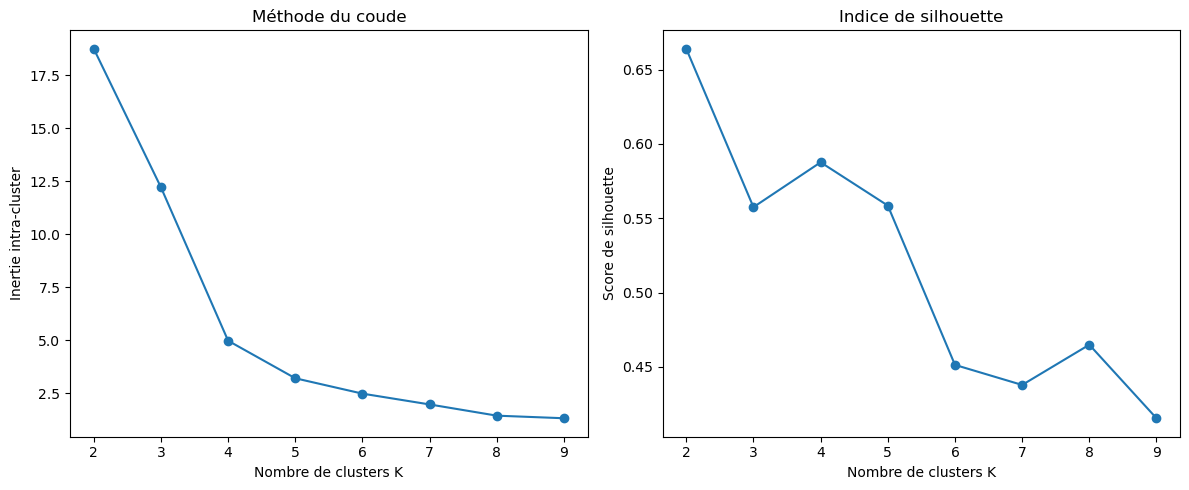

In [34]:
# Importations nécessaires
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

###############################################################################################################
# 1. Chargement et prétraitement des données
df = pd.read_csv("Salary_Data.csv")  # Charger les données
print("Aperçu des données :")
print(df.head())

# Copier les données dans X et vérifier les valeurs manquantes
X = df.copy()
print('Le nombre de valeurs manquantes =', X.isnull().sum().sum())

# Sélectionner uniquement les colonnes numériques (si nécessaire)
X = X.select_dtypes(include=[np.number])  # Conserver uniquement les colonnes numériques

# Mettre à l'échelle les données
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

###############################################################################################################
# 2. Application de K-Means
kmeans = KMeans(n_clusters=3, random_state=0)
df['Cluster'] = kmeans.fit_predict(X_scaled)  # Appliquer K-Means sur les données mises à l'échelle

# Ramener les centres des clusters à l'échelle initiale
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
cluster_counts = df['Cluster'].value_counts().sort_index()

# Afficher les centres des clusters
print("Centres des clusters :")
print(pd.DataFrame(centroids, columns=X.columns))

# Afficher la répartition des clusters
print("Répartition des clusters :")
print(cluster_counts)

###############################################################################################################
# 3. Évaluation du clustering avec K-Means
plt.figure(figsize=(12, 5))

# Calcul de l'inertie et de l'indice de silhouette
K_range = range(2, 10)
inertia = []
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)  # Utiliser les données mises à l'échelle
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))  # Calculer le score de silhouette

# Méthode du coude
plt.subplot(1, 2, 1)
plt.plot(K_range, inertia, marker='o', linestyle='-')
plt.xlabel('Nombre de clusters K')
plt.ylabel('Inertie intra-cluster')
plt.title('Méthode du coude')

# Indice de silhouette
plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, marker='o', linestyle='-')
plt.xlabel('Nombre de clusters K')
plt.ylabel('Score de silhouette')
plt.title('Indice de silhouette')

plt.tight_layout()
plt.show()

In [36]:
La courbe descend rapidement jusqu'à k=4, puis elle s'aplatit (diminue très lentement à partir de k=4).
k=2 donne le meilleur score mathématiquement, mais k=4 est un bon compromis car il est confirmé par la méthode du coude et offre une segmentation plus riche et plus utile métier.
On choisit k=4 car les deux méthodes le confirment comme meilleur choix pratique pour segmenter les salaires en 4 groupes homogènes et interprétables.

SyntaxError: invalid syntax (3784809492.py, line 1)